In [1]:
# librerias
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix,negativity,state_fidelity,Operator,concurrence,entropy,purity
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke


from qiskit_dynamics import Solver, Signal
from qiskit_dynamics.backend import parse_backend_hamiltonian_dict

from qiskit import pulse
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import numpy as np
import random
import sympy as sym

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")



import numpy as np
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

def plot_statevector_probabilities(statevector):
    probabilities = statevector.probabilities()
    num_qubits = int(np.log2(len(probabilities)))
    basis_states = [f"|{i:0{num_qubits}b}⟩" for i in range(2**num_qubits)]
    
    plt.figure(figsize=(10, 5))
    plt.bar(basis_states, probabilities, color='royalblue')
    plt.xlabel('Computational basis states', fontsize=16)
    plt.ylabel('Probability', fontsize=16)
    # plt.title('Measurement Probabilities of Statevector')
    plt.ylim(0, 1.0)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=0,fontsize=16)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()


In [2]:
import numpy as np
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

def plot_statevector_probabilities_qudit(statevector, d=2):
    """
    Grafica probabilidades de un statevector de qudits.
    Usa etiquetas en base d (por defecto qubits: d=2).
    """
    probabilities = statevector.probabilities()
    dim = len(probabilities)
    
    # Número de qudits
    num_qudits = int(round(np.log(dim) / np.log(d)))
    
    # Etiquetas en base d (por ejemplo base=3 para qutrits)
    basis_states = []
    for i in range(dim):
        digits = np.base_repr(i, base=d).zfill(num_qudits)
        basis_states.append(f"|{digits}⟩")
    
    # Gráfico
    plt.figure(figsize=(12,5))
    plt.bar(basis_states, probabilities, color='royalblue')
    plt.xlabel(f'Computational basis states (d={d})',fontsize=20)
    plt.ylabel('Probability',fontsize=20)
    plt.title(f'Measurement Probabilities of {num_qudits} qudits (d={d})',fontsize=20)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=0,fontsize=16)
    plt.yticks(fontsize=14)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [4]:
# Llamar fake backend
backend = FakeSherbrooke()

#configuracion de backend
propiedades = backend.properties()
configuracion = backend.configuration()


Hz = 1e9
# Definicion de la frecuencia de los qubits en GHz
w7   = configuracion.hamiltonian.get("vars").get("wq7")
w8   = configuracion.hamiltonian.get("vars").get("wq8")
w9   = configuracion.hamiltonian.get("vars").get("wq9")
# anamornicidad de los qubits en GHz
delta7 = configuracion.hamiltonian.get("vars").get("delta7")
delta8 = configuracion.hamiltonian.get("vars").get("delta8")
delta9 = configuracion.hamiltonian.get("vars").get("delta9")
# acoples en GHz
J78 = configuracion.hamiltonian.get("vars").get("jq7q8")
J89 = configuracion.hamiltonian.get("vars").get("jq8q9")
# fuerza de control en GHz
r0   =  configuracion.hamiltonian.get("vars").get("omegad7")
r1   =  configuracion.hamiltonian.get("vars").get("omegad8")
r2   =  configuracion.hamiltonian.get("vars").get("omegad9")
# tiempo de gate en ns
dt = backend.dt*1e9


v7 = w7 /(2*np.pi)
v8 = w8 /(2*np.pi)
v9 = w9 /(2*np.pi)
print(w7, w8, w9)
print(J78, J89)
print(r0,r1,r2)


29.88023890323631 30.23802708662245 29.13898918259225
0.012651918734551187 0.014172096168429698
0.39575797919595557 0.6501466069370565 0.3148551427122911


In [5]:
# Definir los operadores 
dim = 2
a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident = np.eye(dim, dtype=complex)
full_ident = np.eye(dim**2, dtype=complex)

N0 = np.kron(ident,np.kron(ident, N))
N1 = np.kron(ident,np.kron(N, ident))
N2 = np.kron(np.kron(N, ident),ident)

a0 = np.kron(ident,np.kron(ident, a))
a1 = np.kron(ident,np.kron(a, ident))
a2 = np.kron(np.kron(a, ident),ident)


a0dag = np.kron(ident,np.kron(ident, adag))
a1dag = np.kron(ident,np.kron(adag, ident))
a2dag = np.kron(np.kron(adag, ident),ident)

# Haniltoniano del sistema
static_ham = 2*np.pi*v7 * N0  +2*np.pi*v8 * N1  + 2*np.pi*v9* N2   + J78*(a0dag @ a1 +  a0 @ a1dag) + J89*(a1dag @ a2 +  a1 @ a2dag)

# Hamiltonianos de controles
H_drive7 =  r0 * (a0 + a0dag)
H_drive8 =  r1 * (a1 + a1dag)
H_drive9 =  r2 * (a2 + a2dag)
  

y0  = Statevector.from_label("000")

In [6]:

propiedades.qubit_property(3,name='frequency')

(4747181100.193296,
 datetime.datetime(2025, 2, 26, 14, 43, 10, tzinfo=tzoffset(None, -18000)))

In [7]:
solver = Solver(
    static_hamiltonian=static_ham,
    hamiltonian_operators=[H_drive7, H_drive8, H_drive9, H_drive7, H_drive8],
    hamiltonian_channels=["d0", "d1", "d2", "u0", "u1"],
    channel_carrier_freqs= {"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
    dt=dt,
    array_library="jax",
)

In [8]:
from qiskit import pulse

def esque_pul(params):
    t_0, t_1, t_2, t_3,A0, A1, A2, A3, A4  = params

    # Convertir a enteros por requerimiento del backend
    t_0 = int(t_0)
    t_1 = int(t_1)
    t_2 = int(t_2)
    t_3 = int(t_3)
    
    with pulse.build(name="GHZ Pulse") as kp:
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        d2 = pulse.DriveChannel(2)
        u0 = pulse.ControlChannel(0)
        u1 = pulse.ControlChannel(1)

        # Primer pulso en d0 y d1
        pulse.play(pulse.Constant(duration=t_0, amp=A0), d0)
        pulse.play(pulse.Constant(duration=t_0, amp=A1), d1)
           
        # Delay en canal u0
        pulse.delay(duration= t_0 + 1, channel=u0)
        
        # Segundo pulso en d1 y u0
        pulse.play(pulse.Constant(duration = t_1 , amp=A2), u0)
        
      #  # delay pulso d2 y u1 
        pulse.delay(duration= (t_0 + t_1 + 1 ), channel= d2)
        pulse.delay(duration= (t_0+ t_1 + t_2 + 2  ), channel= u1)
        
        
      #   # pulsos locales d1 y d2 
        pulse.play(pulse.Constant(duration=t_2, amp=A3),d2)
      #   # pulse.play(pulse.Constant(duration=t_2, amp=A4),d1)
        
      #  # pulso local d2
        # pulse.play(pulse.Constant(duration=t_3, amp=A4),d2)
           
      # # pulso u1
        pulse.play(pulse.Constant(duration=t_3, amp=A4),u1)
        
    return kp


In [40]:
def objective_12(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    return yf

def evol_GHZ(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        atol=1e-7,
        rtol=1e-8
    )
    
    return sol

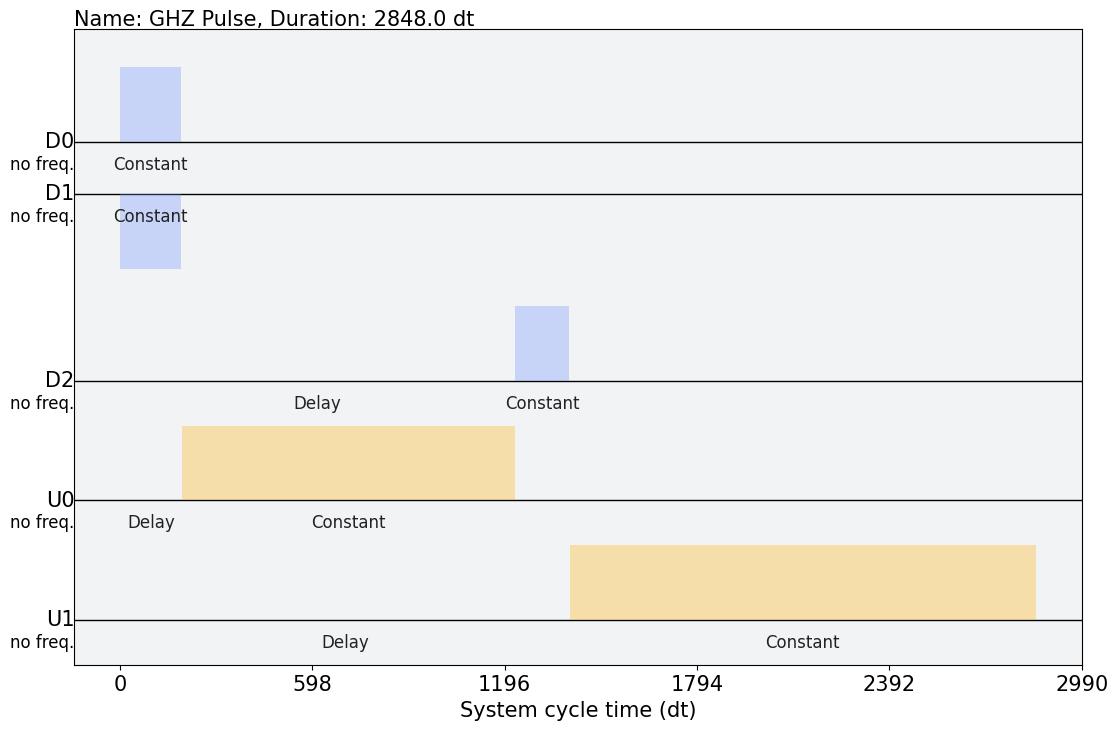

In [20]:
parametros_optimos =  [
        202.9295423047658,
        1258.1648854894204,
        192.1238241246524,
        1860.2496455494108,
        0.4302391752867789,
        -0.05416696911702623,
        0.45105849258854414,
        0.5052878150042629,
        -0.48319328703627806,
       ]

x =  [ 2.02977227e+02,  1.24590825e+03,  1.92893062e+02,  1.85898891e+03,
  4.30640491e-01, -5.69626179e-02,  4.51052541e-01,  5.10797206e-01,
 -4.79180337e-01]



x0 =[ 2.02009625e+02,  1.27298658e+03,  1.75001941e+02,  1.81997862e+03,
  4.29963073e-01, -7.70238654e-02,  4.52135477e-01,  3.83286156e-01,
 -4.91208525e-01]


x1 =  [ 1.90153970e+02,  1.06419199e+03,  1.59748288e+02,  1.47613390e+03,
  4.87011015e-01, -6.46923991e-01,  6.63427649e-01,  1.64118785e-01,
  6.30356450e-01]

x2 = [ 1.91779586e+02,  1.03750354e+03,  1.68736170e+02,  1.45046248e+03,
  4.90394435e-01, -6.91612520e-01,  6.65492967e-01,  1.65200193e-01,
  6.19735822e-01]

X_GHZ =  [
    1.91779586e+02, 1.03750354e+03, 1.68736170e+02, 1.45046248e+03,
    4.90394435e-01, -6.91612520e-01, 6.65492967e-01, 1.65200193e-01,
    6.19735822e-01
]

esque_pul(X_GHZ).draw()

In [21]:
objective_12(X_GHZ).draw("latex_source")

'(-0.325087979 + 0.5835832978 i) |000\\rangle+(-0.1429269432 - 0.0194928303 i) |001\\rangle+(0.0210944001 - 0.1113714689 i) |010\\rangle+(-0.0104351663 - 0.1369005982 i) |011\\rangle+(0.1206952367 + 0.0296263868 i) |100\\rangle+(0.1283407639 - 0.0084041756 i) |101\\rangle+(0.0318967537 + 0.1532438365 i) |110\\rangle+(0.4245584034 - 0.5142986054 i) |111\\rangle'

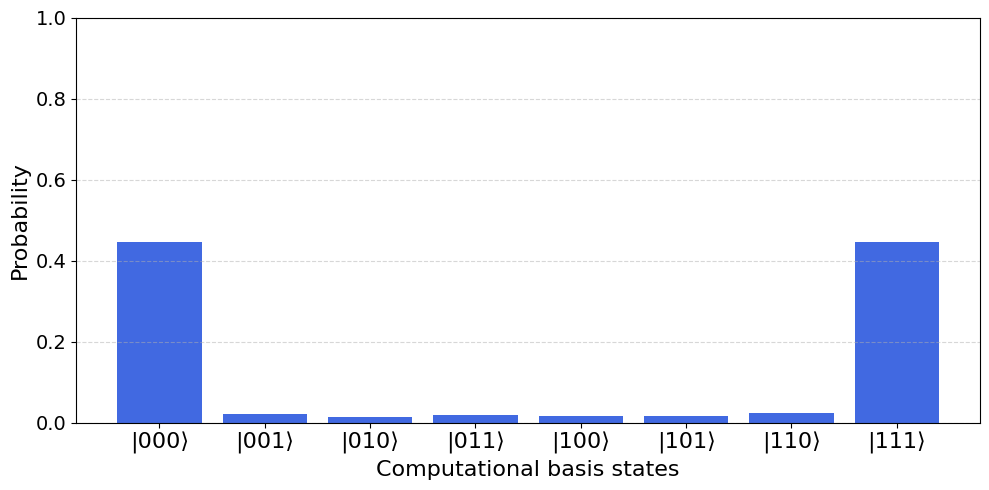

In [22]:
plot_statevector_probabilities(objective_12(X_GHZ))

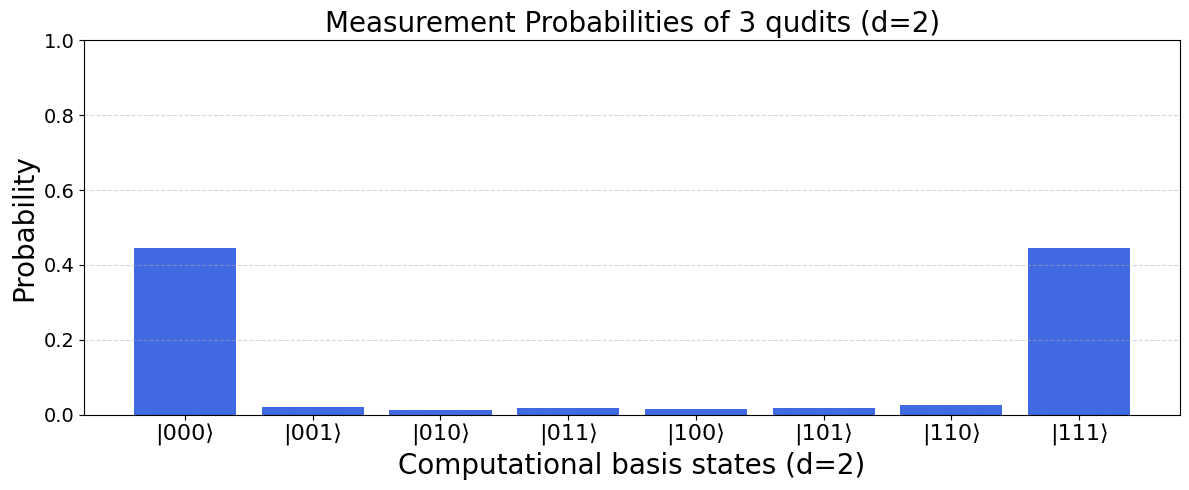

In [23]:
plot_statevector_probabilities_qudit(objective_12(X_GHZ), d=2)

In [24]:

def three_t(yf):
    m1 = (yf[0] * yf[7])**2 + (yf[1] * yf[6])**2 + (yf[2] * yf[5])**2 + (yf[3] * yf[4])**2
    m2 = (yf[0] * yf[7] * yf[3] * yf[4] + yf[0] * yf[7] * yf[5] * yf[2] +
          yf[0] * yf[7] * yf[6] * yf[1] + yf[3] * yf[4] * yf[5] * yf[2] +
          yf[3] * yf[4] * yf[6] * yf[1] + yf[5] * yf[2] * yf[6] * yf[1])
    m3 = yf[0] * yf[6] * yf[5] * yf[3] + yf[7] * yf[1] * yf[2] * yf[4]
    tau =  4 * abs(m1 - 2 * m2 + 4 * m3)
    return tau

def three_tangle(psi):
    """
    Calcula el three-tangle τ_ABC para un estado puro de tres qubits.

    Parámetro:
        psi: Statevector de 3 qubits (dim=8)

    Retorna:
        tau_ABC: float
    """
    rho_A = partial_trace(psi, [1, 2])   # traza sobre B y C
    C_A_BC = np.sqrt(2 * (1 - np.trace(rho_A.data @ rho_A.data).real))

    # Concurrencia entre pares, calculada con concurrencia de Qiskit
    rho_AB = partial_trace(psi, [2])  # traza sobre qubit C
    C_AB = concurrence(rho_AB)

    rho_AC = partial_trace(psi, [1])  # traza sobre qubit B
    C_AC = concurrence(rho_AC)

    tau_ABC = C_A_BC**2 - C_AB**2 - C_AC**2
    return np.clip(tau_ABC, 0, 1)

In [25]:
three_tangle(objective_12(X_GHZ))

np.float64(0.9994767248130607)

In [26]:
three_t(objective_12(X_GHZ))

np.float64(0.9994767247185403)

In [27]:
negativity(objective_12(X_GHZ),[0])

np.float64(0.49999874071408423)

In [28]:
negativity(objective_12(X_GHZ),[2])

np.float64(0.4998719277262649)

In [29]:
negativity(objective_12(X_GHZ),[1])

np.float64(0.4999961990286653)

In [37]:
import gc
gc.collect()

0

In [41]:
GHZ_evol = evol_GHZ(X_GHZ)

In [43]:
len(GHZ_evol.t)

51399

In [75]:
negativity_values0 = []
negativity_values1 = []
negativity_values2 = []
for i in range(len(GHZ_evol.t)):
    negativity_values0.append(negativity(GHZ_evol.y[i], [0]))
    negativity_values1.append(negativity(GHZ_evol.y[i], [1]))
    negativity_values2.append(negativity(GHZ_evol.y[i], [2]))

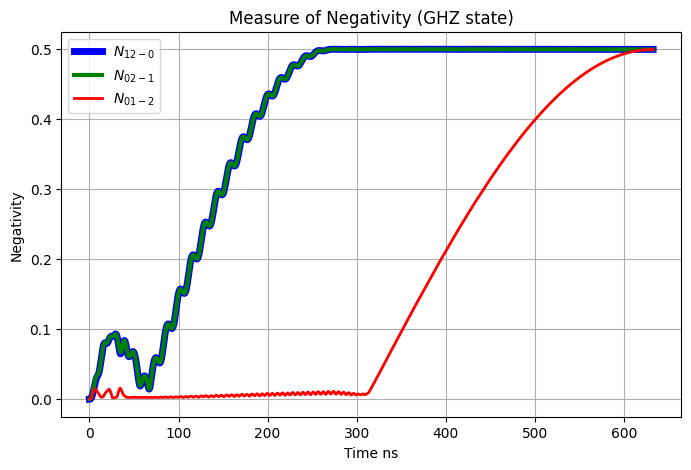

In [83]:
plt.figure(figsize=(8, 5))

plt.plot(GHZ_evol.t, negativity_values0, linewidth=5, color='blue', label="$N_{12-0}$")
plt.plot(GHZ_evol.t, negativity_values1, linewidth=3, color='green', label="$N_{02-1}$")
plt.plot(GHZ_evol.t, negativity_values2, linewidth=2, color='red', label="$N_{01-2}$")
plt.title("Measure of Negativity (GHZ state)")
plt.xlabel("Time ns")
plt.ylabel("Negativity")
plt.legend()
plt.grid(True)

plt.show()

In [86]:
def plot_populations(sol):
    pop0 = [psi.probabilities()[0] for psi in GHZ_evol.y]
    pop1 = [psi.probabilities()[1] for psi in GHZ_evol.y]
    pop2 = [psi.probabilities()[2] for psi in GHZ_evol.y]
    pop3 = [psi.probabilities()[3] for psi in GHZ_evol.y]
    pop4 = [psi.probabilities()[4] for psi in GHZ_evol.y]
    pop5 = [psi.probabilities()[5] for psi in GHZ_evol.y]
    pop6 = [psi.probabilities()[6] for psi in GHZ_evol.y]
    pop7 = [psi.probabilities()[7] for psi in GHZ_evol.y]

    fig = plt.figure(figsize=(8, 5))
    plt.plot(GHZ_evol.t, pop0, lw=3, label="Population in |000>")
    plt.plot(GHZ_evol.t, pop1, lw=3, label="Population in |001>")
    plt.plot(GHZ_evol.t, pop2, lw=3, label="Population in |010>")
    plt.plot(GHZ_evol.t, pop3, lw=3, label="Population in |011>")
    plt.plot(GHZ_evol.t, pop4, lw=3, label="Population in |100>")
    plt.plot(GHZ_evol.t, pop5, lw=3, label="Population in |101>")
    plt.plot(GHZ_evol.t, pop6, lw=3, label="Population in |110>")
    plt.plot(GHZ_evol.t, pop7, lw=3, label="Population in |111>")
    plt.xlabel("Time (ns)")
    plt.ylabel("Population")
    plt.legend(frameon=False)
    plt.ylim([0, 1.05])
    plt.xlim([0, GHZ_evol.t[-1]])
    # plt.vlines(T, 0, 1.05, "k", linestyle="dashed")

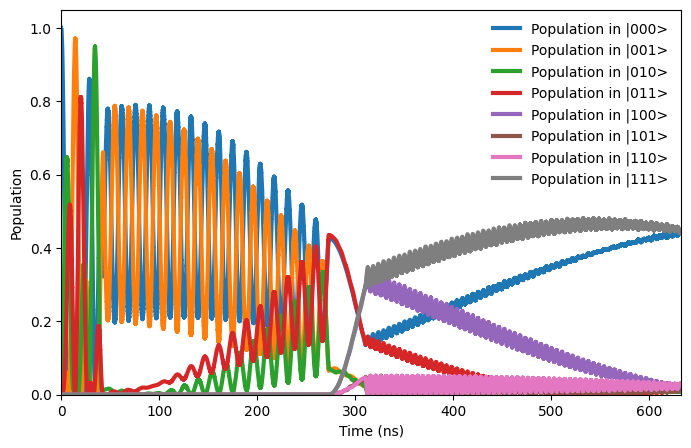

In [87]:
plot_populations(GHZ_evol)

In [57]:
v7 = w7 /(2*np.pi)
v8 = w8 /(2*np.pi)
v9 = w9 /(2*np.pi)
print(w7, w8, w9)
print(J78, J89)
print(r0,r1,r2)

29.88023890323631 30.23802708662245 29.13898918259225
0.012651918734551187 0.014172096168429698
0.39575797919595557 0.6501466069370565 0.3148551427122911


In [56]:
1996*dt

443.55555555555554